# Atividade de vendas no Brasil

Pedro Henrique Ferrari 

## Entregável 1 NumPy

In [ ]:
import pandas as pd 
import numpy as np
df = pd.read_csv("vendas_brasil_1.csv")

preco_unitario = df['preco_unitario'].to_numpy()
custo_unitario = df["custo_unitario"].to_numpy()
quantidade = df["quantidade"].to_numpy()
desconto_pct = df["desconto_pct"].to_numpy()
receita_total = df["receita_total"].to_numpy()
frete = df["frete"].to_numpy()

frete_tratado = np.nan_to_num(frete, nan =0) #Valores NaN estavam aparecendo nos prints

valor_bruto = preco_unitario * quantidade
valor_desconto = valor_bruto * (desconto_pct / 100)
custo_total = custo_unitario * quantidade
lucro_estimado = receita_total - custo_total - frete_tratado

print("Valor bruto:", np.round(valor_bruto[:5], 2))
print("Valor do desconto:", np.round(valor_desconto[:5], 2))
print("Custo total:", np.round(custo_total[:5], 2))
print("Lucro estimado:", np.round(lucro_estimado[:5], 2))

media_receita = np.nanmean(receita_total)

mascara_acima_media = receita_total > media_receita

print("Receita media = ", np.round(media_receita, 2))
print("quantidade de receitas acima da media: ", np.sum(mascara_acima_media))

vendas_prejuizo = lucro_estimado < 0

print("Quantidade de vendas com prejuizo: ", np.sum(vendas_prejuizo))

desconto_alto = desconto_pct >= 25  #Escolhi 25 pois 30 já retornava 0 produtos

print("Quantidade de vendas com desconto alto: ", np.sum(desconto_alto))

maior_receita = np.nanmax(receita_total)
menor_receita = np.nanmin(receita_total)
lucro_medio = np.nanmean(lucro_estimado)

print("Maior receita: ", maior_receita)
print("Menor receita: ", menor_receita)
print("Lucro medio: ", lucro_medio)



Valor bruto: [6417.91    0.    607.36 2988.67 3065.43]
Valor do desconto: [333.73   0.     4.25  17.93 597.76]
Custo total: [5617.5   675.75  859.6   973.83  107.25]
Lucro estimado: [1307.3   254.53  190.92  598.11  -22.5 ]
Receita media =  1891.69
quantidade de receitas acima da media:  9236
Quantidade de vendas com prejuizo:  5960
Quantidade de vendas com desconto alto:  2521
Maior receita:  58430.28
Menor receita:  3.7
Lucro medio:  484.79423266076503


## Entregável 2 Pandas

In [97]:

df.info()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37617 entries, 0 to 37616
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   data_venda          37617 non-null  object 
 1   mes                 37617 non-null  int64  
 2   cidade              37617 non-null  object 
 3   canal_venda         37567 non-null  object 
 4   categoria           37617 non-null  object 
 5   produto             37617 non-null  object 
 6   vendedor            37577 non-null  object 
 7   fidelidade_cliente  37617 non-null  object 
 8   preco_unitario      37617 non-null  float64
 9   custo_unitario      37617 non-null  float64
 10  margem_pct          37535 non-null  float64
 11  quantidade          37617 non-null  int64  
 12  desconto_pct        37617 non-null  float64
 13  receita_total       37617 non-null  float64
 14  frete               35738 non-null  float64
 15  avaliacao_cliente   34662 non-null  float64
 16  praz

data_venda               0
mes                      0
cidade                   0
canal_venda             50
categoria                0
produto                  0
vendedor                40
fidelidade_cliente       0
preco_unitario           0
custo_unitario           0
margem_pct              82
quantidade               0
desconto_pct             0
receita_total            0
frete                 1879
avaliacao_cliente     2955
prazo_entrega_dias    1504
devolucao                0
entrega_no_prazo         0
alta_temporada           0
flag_outlier_preco       0
dtype: int64

1. Quantas linhas e colunas existem?
R: 37617 linhas e 21 colunas

2. Existem dados faltantes?
R: Sim, principalmente nas colunas de frete, avaliação cliente e prazo de entrega

3. Quais colunas parecem numéricas?


            1   mes                 37617 non-null  int64  
            8   preco_unitario      37617 non-null  float64
            9   custo_unitario      37617 non-null  float64
            10  margem_pct          37535 non-null  float64
            11  quantidade          37617 non-null  int64  
            12  desconto_pct        37617 non-null  float64
            13  receita_total       37617 non-null  float64
            14  frete               35738 non-null  float64
            15  avaliacao_cliente   34662 non-null  float64
            16  prazo_entrega_dias  36113 non-null  float64
 
4. Quais colunas parecem categóricas?

            2   cidade              37617 non-null  object 
            3   canal_venda         37567 non-null  object 
            4   categoria           37617 non-null  object 
            5   produto             37617 non-null  object 
            6   vendedor            37577 non-null  object 
            7   fidelidade_cliente  37617 non-null  object 

In [111]:
df['data_venda'] = pd.to_datetime(df['data_venda'], format="mixed",dayfirst=True, errors ="coerce")

print(df["data_venda"].dtype)

df['canal_venda'].value_counts() 

df["canal_venda"] = (
    df["canal_venda"]
    .str.strip()
    .str.lower()
)

df["canal_venda"].value_counts()

canais = {
    "site web": "Site Web",
    "app mobile": "App Mobile",
    "loja física": "Loja Física",
    "marketplace": "Marketplace",
    "televendas": "Televendas",
    "siteweb": "Site Web",
    "loja fisica": "Loja Física",
}

df["canal_venda"] = df["canal_venda"].replace(
    canais
)
df["canal_venda"].value_counts()

#Dados faltantes que apareceram em peso no isnan.sum, preenchendo com a mediana
df["frete"] = df["frete"].fillna(df["frete"].median())

df["avaliacao_cliente"] = df["avaliacao_cliente"].fillna(df["avaliacao_cliente"].median())

df["prazo_entrega_dias"] = df["prazo_entrega_dias"].fillna(df["prazo_entrega_dias"].median())

df["margem_pct"] = df["margem_pct"].fillna(df["margem_pct"].median())

#Dados categoricos

df["canal_venda"] = df["canal_venda"].fillna("Desconhecido")

df["vendedor"] = df["vendedor"].fillna("Desconhecido")

#Criaçao de novas colunas

df["ano_venda"] = df["data_venda"].dt.year
df["mes_venda"] = df["data_venda"].dt.month
df["custo_total"] = (df["custo_unitario"] * df["quantidade"])
df["lucro_total"] = (df["receita_total"]- df["custo_total"]- df["frete"])

limite_baixo = df["receita_total"].quantile(0.25)
limite_alto = df["receita_total"].quantile(0.75)

df["faixa_receita"] = df["receita_total"].apply(
    lambda valor: "Baixa"
    if valor <= limite_baixo
    else (
        "Alta"
        if valor >= limite_alto
        else "Média"
    )
)

#Filtros

receita_acima_5000 = df[df['receita_total'] > 5000] #Aqui filtramos as vendas com mais de 5000 reais de receita
display(receita_acima_5000.head(10))

devolucao = df[df['devolucao'] == True] #Aqui encontramos todas as vendas que tiveram devolucao
display(devolucao.head(10))

eletronicos = df[df['categoria'] == 'Eletrônicos'] #Aqui pegamos todas as vendas de eletronicos
display(eletronicos.head(10))


#Agrupamentos
receita_por_categoria = df.groupby('categoria')['receita_total'].sum().sort_values(ascending = False)
display(receita_por_categoria)

vendas_por_canal = df.groupby('canal_venda').size().sort_values(ascending = False)
display(vendas_por_canal)

#As linhas estavam estranhas 
df["cidade"] = df["cidade"].str.split().str.join(" ")

correcao_cidades = {
    "BH": "Belo Horizonte",
    "B. Horizonte": "Belo Horizonte",
    "Belo horizonte": "Belo Horizonte",

    "RJ": "Rio de Janeiro",
    "Rio": "Rio de Janeiro",
    "Rio De Janeiro": "Rio de Janeiro",
    "Rio de janeiro": "Rio de Janeiro",

    "SP": "São Paulo",
    "S. Paulo": "São Paulo",
    "Sao Paulo": "São Paulo",
    "São paulo": "São Paulo",

    "Curtiba": "Curitiba",
    "curitiba": "Curitiba",

    "salvador": "Salvador",
    "Slavador": "Salvador"
}
df["cidade"] = df["cidade"].replace(correcao_cidades)
receita_por_cidade = df.groupby('cidade')['receita_total'].sum().sort_values(ascending = False)
display(receita_por_cidade)

#Merge
tabela_regioes = pd.DataFrame({
    "cidade": [
        "São Paulo",
        "Rio de Janeiro",
        "Belo Horizonte",
        "Curitiba",
        "Porto Alegre",
        "Salvador",
        "Recife",
        "Fortaleza",
        "Manaus",
        "Goiânia"
    ],
    "regiao": [
        "Sudeste",
        "Sudeste",
        "Sudeste",
        "Sul",
        "Sul",
        "Nordeste",
        "Nordeste",
        "Nordeste",
        "Norte",
        "Centro-Oeste"
    ]
})

tabela_regioes

df_merge = df.merge(tabela_regioes, on='cidade', how='left')

df_merge[["cidade", "regiao",'receita_total']].head()

datetime64[ns]


,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco,ano_venda,mes_venda,custo_total,lucro_total,faixa_receita,ano_mes
0,2022-04-13,4,Rio de Janeiro,App Mobile,Eletrônicos,Notebook,Bruno Souza,Diamante,739.39,561.75,...,False,True,False,False,2022.0,4.0,5617.50,1307.30,Alta,2022-04-01
15,2022-04-10,4,Salvador,Marketplace,Eletrônicos,Smartphone,Ana Lima,Bronze,1213.88,843.05,...,False,False,False,True,2022.0,4.0,5901.35,1997.43,Alta,2022-04-01
20,2022-12-10,12,Recife,Site Web,Eletrônicos,Smartphone,Inês Nunes,Prata,603.40,394.18,...,False,True,True,False,2022.0,12.0,5518.52,5659.01,Alta,2022-12-01
21,2023-05-07,5,São Paulo,Loja Física,Eletrônicos,Smartwatch,Gabi Alves,Bronze,892.83,660.58,...,True,True,False,True,2023.0,5.0,5284.64,1552.92,Alta,2023-05-01
25,2022-10-04,10,Rio de Janeiro,Loja Física,Eletrônicos,Smartwatch,Bruno Souza,Diamante,449.00,293.50,...,False,True,False,False,2022.0,10.0,4109.00,940.20,Alta,2022-10-01
28,2022-11-10,11,Curitiba,Marketplace,Eletrônicos,Smartphone,Bruno Souza,Ouro,815.68,573.68,...,True,True,True,False,2022.0,11.0,6310.48,2576.94,Alta,2022-11-01
45,2023-04-30,4,São Paulo,Site Web,Eletrônicos,Smartwatch,Gabi Alves,Bronze,1219.84,991.94,...,False,True,False,True,2023.0,4.0,10911.34,2481.19,Alta,2023-04-01
50,2023-01-23,1,Porto Alegre,Site Web,Eletrônicos,Fone Bluetooth,Ana Lima,Prata,716.90,531.74,...,False,True,True,False,2023.0,1.0,6380.88,5544.41,Alta,2023-01-01
52,2022-11-12,11,São Paulo,Site Web,Eletrônicos,Fone Bluetooth,Diego Ferreira,Bronze,963.11,628.48,...,False,False,True,True,2022.0,11.0,3770.88,4863.01,Alta,2022-11-01
58,2022-04-02,4,Curitiba,Loja Física,Eletrônicos,Fone Bluetooth,Bruno Souza,Prata,651.03,530.99,...,False,True,False,False,2022.0,4.0,6902.87,1519.74,Alta,2022-04-01


,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco,ano_venda,mes_venda,custo_total,lucro_total,faixa_receita,ano_mes
1,2023-03-12,3,Manaus,Site Web,Vestuário,Camiseta,Elisa Costa,Bronze,187.48,135.15,...,True,False,False,False,2023.0,3.0,675.75,232.28,Média,2023-03-01
2,2022-09-28,9,Goiânia,App Mobile,Vestuário,Tênis,João Vieira,Bronze,76.11,61.40,...,True,True,False,False,2022.0,9.0,859.60,190.92,Média,2022-09-01
7,2023-09-07,9,Manaus,App Mobile,Alimentação,Mel Orgânico,Inês Nunes,Prata,35.72,21.62,...,True,False,False,False,2023.0,9.0,129.72,26.65,Baixa,2023-09-01
18,2023-10-24,10,Manaus,Site Web,Vestuário,Camiseta,Carla Mendes,Prata,65.73,41.26,...,True,True,False,False,2023.0,10.0,165.04,43.11,Baixa,2023-10-01
21,2023-05-07,5,São Paulo,Loja Física,Eletrônicos,Smartwatch,Gabi Alves,Bronze,892.83,660.58,...,True,True,False,True,2023.0,5.0,5284.64,1552.92,Alta,2023-05-01
28,2022-11-10,11,Curitiba,Marketplace,Eletrônicos,Smartphone,Bruno Souza,Ouro,815.68,573.68,...,True,True,True,False,2022.0,11.0,6310.48,2576.94,Alta,2022-11-01
39,2023-11-18,11,Recife,Site Web,Livros,Estatística Aplicada,Diego Ferreira,Bronze,48.15,40.39,...,True,True,True,False,2023.0,11.0,444.29,110.88,Média,2023-11-01
68,2022-01-02,1,Manaus,Marketplace,Vestuário,Tênis,Elisa Costa,Bronze,94.40,63.81,...,True,False,True,False,2022.0,1.0,829.53,488.10,Média,2022-01-01
76,2023-07-10,7,Salvador,Loja Física,Livros,Machine Learning,Inês Nunes,Bronze,99.36,80.05,...,True,True,False,False,2023.0,7.0,560.35,-54.43,Média,2023-07-01
85,2023-12-03,12,Recife,App Mobile,Eletrônicos,Notebook,Carla Mendes,Diamante,702.50,440.84,...,True,True,True,False,2023.0,12.0,5290.08,4711.30,Alta,2023-12-01


,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco,ano_venda,mes_venda,custo_total,lucro_total,faixa_receita,ano_mes
0,2022-04-13,4,Rio de Janeiro,App Mobile,Eletrônicos,Notebook,Bruno Souza,Diamante,739.39,561.75,...,False,True,False,False,2022.0,4.0,5617.50,1307.30,Alta,2022-04-01
15,2022-04-10,4,Salvador,Marketplace,Eletrônicos,Smartphone,Ana Lima,Bronze,1213.88,843.05,...,False,False,False,True,2022.0,4.0,5901.35,1997.43,Alta,2022-04-01
17,2022-05-11,5,Belo Horizonte,App Mobile,Eletrônicos,Smartwatch,Elisa Costa,Prata,732.37,536.37,...,False,True,False,False,2022.0,5.0,3218.22,47.65,Alta,2022-05-01
20,2022-12-10,12,Recife,Site Web,Eletrônicos,Smartphone,Inês Nunes,Prata,603.40,394.18,...,False,True,True,False,2022.0,12.0,5518.52,5659.01,Alta,2022-12-01
21,2023-05-07,5,São Paulo,Loja Física,Eletrônicos,Smartwatch,Gabi Alves,Bronze,892.83,660.58,...,True,True,False,True,2023.0,5.0,5284.64,1552.92,Alta,2023-05-01
25,2022-10-04,10,Rio de Janeiro,Loja Física,Eletrônicos,Smartwatch,Bruno Souza,Diamante,449.00,293.50,...,False,True,False,False,2022.0,10.0,4109.00,940.20,Alta,2022-10-01
28,2022-11-10,11,Curitiba,Marketplace,Eletrônicos,Smartphone,Bruno Souza,Ouro,815.68,573.68,...,True,True,True,False,2022.0,11.0,6310.48,2576.94,Alta,2022-11-01
32,2023-04-20,4,Recife,Site Web,Eletrônicos,Smartphone,Diego Ferreira,Prata,894.76,643.95,...,False,True,False,True,2023.0,4.0,643.95,204.34,Média,2023-04-01
43,2023-05-20,5,Salvador,Site Web,Eletrônicos,Notebook,Elisa Costa,Bronze,299.80,226.74,...,False,True,False,False,2023.0,5.0,1813.92,268.83,Alta,2023-05-01
44,2022-05-11,5,Recife,Loja Física,Eletrônicos,Tablet,Ana Lima,Bronze,797.74,634.46,...,False,False,False,False,2022.0,5.0,3172.30,389.15,Alta,2022-05-01


categoria
Eletrônicos    45017479.88
Esportes       11567480.75
Vestuário       6780473.93
Livros          4462597.93
Alimentação     3331601.51
Name: receita_total, dtype: float64

canal_venda
Site Web        11346
App Mobile      11258
Loja Física      7498
Marketplace      5604
Televendas       1861
desconhecido       50
dtype: int64

cidade
Recife            7662241.79
Manaus            7459161.23
Fortaleza         7242081.82
Goiânia           7178113.69
Porto Alegre      7048428.17
Curitiba          6993175.07
Salvador          6918656.01
Belo Horizonte    6914747.61
Rio de Janeiro    6880176.34
São Paulo         6862852.27
Name: receita_total, dtype: float64

,cidade,regiao,receita_total
0,Rio de Janeiro,Sudeste,6933.48
1,Manaus,Norte,930.28
2,Goiânia,Centro-Oeste,1058.50
3,Fortaleza,Nordeste,1592.43
4,Belo Horizonte,Sudeste,107.64


Uma coluna que investiguei foi essa que informa o canal de venda utilizado. Verifiquei que algumas categorias se repetiam, com diferenças de acentuação, letras maiusculas ou nomes juntos/separados. Para resolver isso, tirei todos os espaços no inicio e fim e criei um dicionario que padroniza todas essas diferenças 

Antes:

            canal_venda
            site web       11315
            app mobile     11258
            loja física     7467
            marketplace     5604
            televendas      1861
            siteweb           31
            loja fisica       31
            Name: count, dtype: int64

Depois:

            canal_venda
            Site Web       11346
            App Mobile     11258
            Loja Física     7498
            Marketplace     5604
            Televendas      1861
            Name: count, dtype: int64            

A coluna de data da venda foi convertida para datetime. Além disso, algumas colunas como frete e avaliação, preenchi as linhas com NaN com a mediana das linhas com valores. Dados categoricos como canal de venda e vendedor, preenchi os Nan com "Desconhecido". 

Nos agrupamentos, tive que tratar a coluna cidade que carregava diversas variações dos nomes, fazendo split e join + um dicionario que corrigia esses nomes. Em seguida, com isso feito, foi possivel realizar o merge com uma tabela que relaciona cidades com as regioes do Brasil. 

## Entregável 3 Seaborn

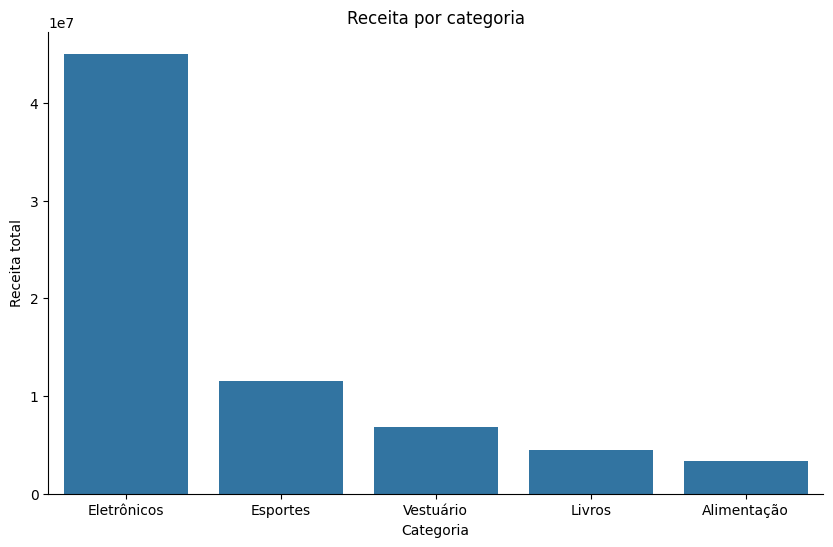

In [99]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
receita_por_categoria = df.groupby('categoria')['receita_total'].sum().sort_values(ascending = False).reset_index()
sns.barplot(data=receita_por_categoria, x='categoria', y='receita_total')

plt.title("Receita por categoria")
plt.xlabel("Categoria")
plt.ylabel("Receita total")

sns.despine()
plt.show()

Eletronicos lideram a receita total de vendas

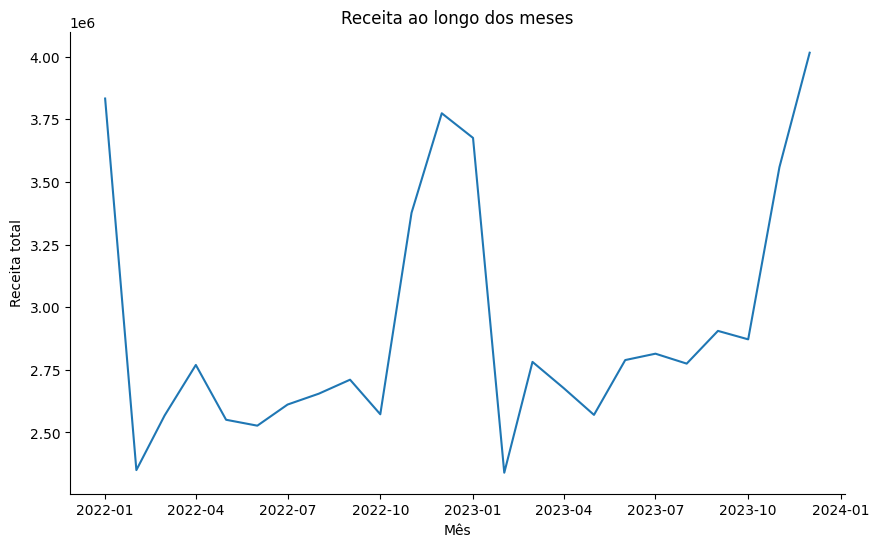

In [102]:
df["ano_mes"] = df["data_venda"].dt.to_period("M").dt.to_timestamp()

receita_mensal = df.groupby("ano_mes", as_index=False)["receita_total"].sum()

plt.figure(figsize=(10,6))

sns.lineplot(data=receita_mensal, x='ano_mes', y='receita_total')

plt.title("Receita ao longo dos meses")
plt.xlabel("Mês")
plt.ylabel("Receita total")
sns.despine()
plt.show()

Deu pra perceber que as vendas aumentam consideravelmente no fim do ano!! Epoca de natal, ferias, etc, pode ser uma hipotese para esse aumento

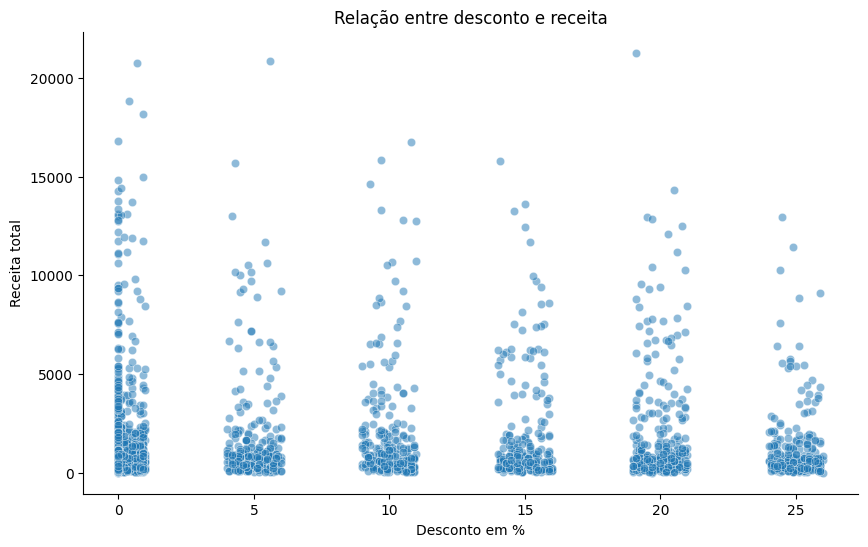

In [ ]:
plt.figure(figsize=(10,6))
amostra = df.sample(n=min(2000, len(df)), random_state = 42) #O grafico estava ficando bizarro porque são muitas linhas, uma amostra menor deu pra visualizar melhor.

sns.scatterplot(data=amostra, x='desconto_pct', y='receita_total', alpha = 0.5)

plt.title("Relação entre desconto e receita")
plt.xlabel("Desconto em %")
plt.ylabel("Receita total")
sns.despine()
plt.show()

Podemos ver que os pontos estao agrupados de 5 em 5%, mostrando que provavelmente os descontos são fixos e crescem de 5% em 5%. Acredito que, como os pontos estão distribuidos de maneira muito semelhante, o desconto não tem grande impacto na receita total. Ou seja, dar mais desconto não gera maior receita e nem vice versa. 

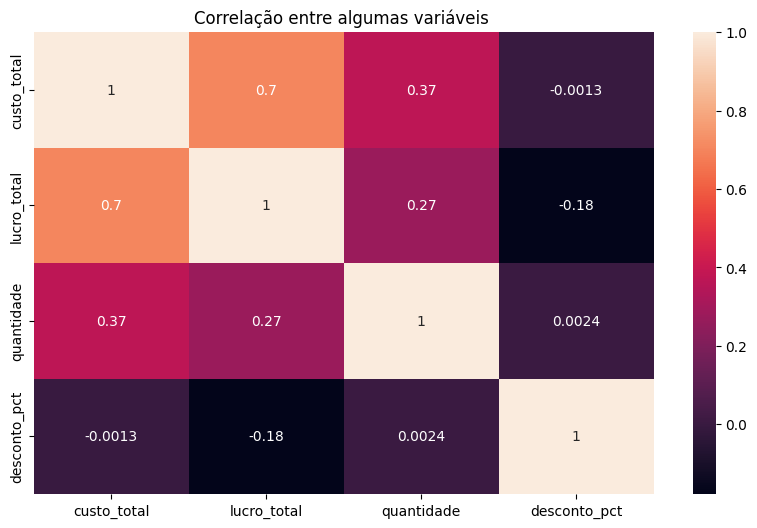

In [108]:
plt.figure(figsize=(10,6))
colunas = ["custo_total", "lucro_total", "quantidade", "desconto_pct"]
sns.heatmap(df[colunas].corr(), annot=True)

plt.title("Correlação entre algumas variáveis ")
plt.show()

Algumas interpretações para esse mapa são: 

-O desconto tem correlaçao negativa com o lucro total, ou seja, conforme o desconto aumenta, o lucro total diminui. 

-A correlaçao entre volume e desconto, 0.0024, indica que dar desconto não necessariamente estimula uma compra de mais quantidade de produtos...
 